## Business Understanding

The company FoodHub is a food delivery aggregator
Customer orders food through the FoodHub app.
Restaurant accepts the order.
FoodHub assigns a delivery person.
Delivery person:
Goes to the restaurant
Picks up the order
Delivers it to the customer
Customer rates the order.
FoodHub earns a commission from restaurants.
## objective
The food aggregator company has stored the data of the different orders made by the 
registered customers in their online portal. They want to analyze the data to get a fair idea 
about the demand of different restaurants which will help them in enhancing their customer 
experience ,data analysis to find answers to these questions that will help the company to improve the business.  

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [57]:
foodhub_df=pd.read_csv("data/foodhub_order.csv")

In [58]:
foodhub_df.head(5)

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [59]:
foodhub_df.tail(5)

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
1893,1476701,292602,Chipotle Mexican Grill $1.99 Delivery,Mexican,22.31,Weekend,5,31,17
1894,1477421,397537,The Smile,American,12.18,Weekend,5,31,19
1895,1477819,35309,Blue Ribbon Sushi,Japanese,25.22,Weekday,Not given,31,24
1896,1477513,64151,Jack's Wife Freda,Mediterranean,12.18,Weekday,5,23,31
1897,1478056,120353,Blue Ribbon Sushi,Japanese,19.45,Weekend,Not given,28,24


In [60]:
rows,columns=foodhub_df.shape 
output=f"RECORDS:{rows}|| FEATURES {columns}"
print(output)

RECORDS:1898|| FEATURES 9


In [61]:
foodhub_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   str    
 3   cuisine_type           1898 non-null   str    
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   str    
 6   rating                 1898 non-null   str    
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 133.6 KB


In [62]:
foodhub_df.columns

Index(['order_id', 'customer_id', 'restaurant_name', 'cuisine_type',
       'cost_of_the_order', 'day_of_the_week', 'rating',
       'food_preparation_time', 'delivery_time'],
      dtype='str')

In [63]:
foodhub_df.isna().sum() ## no missing values

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64

In [64]:
foodhub_df.duplicated().sum() # here no duplicates

np.int64(0)

In [65]:
foodhub_df.dtypes

order_id                   int64
customer_id                int64
restaurant_name              str
cuisine_type                 str
cost_of_the_order        float64
day_of_the_week              str
rating                       str
food_preparation_time      int64
delivery_time              int64
dtype: object

In [66]:
foodhub_df.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


insights
- food preparation- shortest time to prep is 20 min while the longest is 35 mins
- delivery time- the range of delivery time is 18 mins

In [67]:
foodhub_df.describe(include='object') ## categorical

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_24644\4105046646.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  foodhub_df.describe(include='object') ## categorical


,restaurant_name,cuisine_type,day_of_the_week,rating
count,1898,1898,1898,1898
unique,178,14,2,4
top,Shake Shack,American,Weekend,Not given
freq,219,584,1351,736


insight:
- restraunt shake shack has most orders on weekends and its mostly the american cusine.

## popular restraurant

In [68]:
foodhub_df['restaurant_name'].value_counts().head()

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64

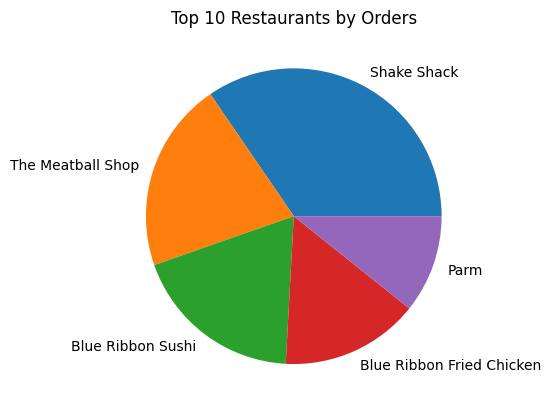

In [69]:
foodhub_df['restaurant_name'].value_counts().head().plot(kind='pie')
plt.title("Top 10 Restaurants by Orders")
plt.show()

insight:
- shake shack is the most ordered from restaraunt
- add more staff
- more delivery guys
- expand the structure


## popular cuisine

In [70]:
foodhub_df['cuisine_type'].value_counts()

cuisine_type
American          584
Japanese          470
Italian           298
Chinese           215
Mexican            77
Indian             73
Middle Eastern     49
Mediterranean      46
Thai               19
French             18
Southern           17
Korean             13
Spanish            12
Vietnamese          7
Name: count, dtype: int64

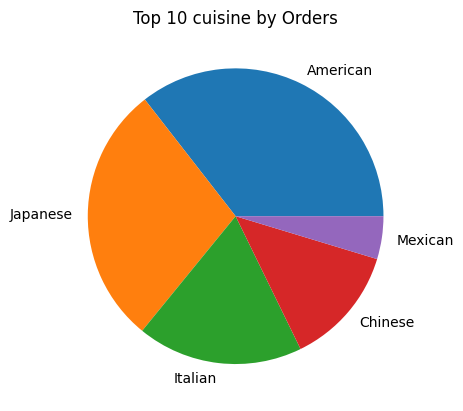

In [71]:
foodhub_df['cuisine_type'].value_counts().head().plot(kind='pie')
plt.title("Top 10 cuisine by Orders")
plt.show()

insight:
- the american cuisine is majorly ordered for

## average delivery time

In [72]:
foodhub_df['delivery_time'].mean()

np.float64(24.161749209694417)

insight:
- the food takes averagely 24 mins to be delivered

## which day has more orders?

In [73]:
foodhub_df['day_of_the_week'].value_counts()

day_of_the_week
Weekend    1351
Weekday     547
Name: count, dtype: int64

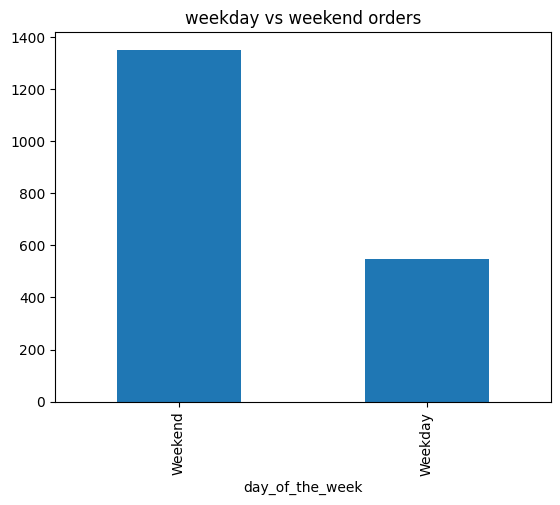

In [74]:
foodhub_df['day_of_the_week'].value_counts().head().plot(kind='bar')
plt.title("weekday vs weekend orders")
plt.show()

insight:
- the weekends has more orders obviously

## food preparation time

In [75]:
foodhub_df['food_preparation_time'].mean()

np.float64(27.371970495258168)

insight:
- 27 mins for food prepping after ordering

## ratings

In [79]:
foodhub_df.groupby('restaurant_name')['rating'].mean().sort_values(ascending=False)

TypeError: dtype 'str' does not support operation 'mean'